In [122]:
import pandas as pd


In [123]:
df=pd.read_csv("/content/matches.csv")

In [124]:
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [125]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 1095
Columns: 20


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [127]:
df.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [128]:
rename_map = {
    "Rising Pune Supergaint"       : "Rising Pune Supergiants",
    "Rising Pune Supergiant"       : "Rising Pune Supergiants",
    "Royal Challengers Bangalore"  : "Royal Challengers Bengaluru",
    "Delhi Daredevils"             : "Delhi Capitals",
    "Kings XI Punjab"              : "Punjab Kings",
}

df["winner"] = df["winner"].replace(rename_map)

In [129]:

print(df["winner"].value_counts())

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Punjab Kings                   112
Rajasthan Royals               112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


In [130]:
print(df["winner"])

0             Kolkata Knight Riders
1               Chennai Super Kings
2                    Delhi Capitals
3       Royal Challengers Bengaluru
4             Kolkata Knight Riders
                   ...             
1090            Sunrisers Hyderabad
1091          Kolkata Knight Riders
1092               Rajasthan Royals
1093            Sunrisers Hyderabad
1094          Kolkata Knight Riders
Name: winner, Length: 1095, dtype: object


In [131]:
df[["season","team1","team2","winner"]].head()

,season,team1,team2,winner
0,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Kolkata Knight Riders
1,2007/08,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings
2,2007/08,Delhi Daredevils,Rajasthan Royals,Delhi Capitals
3,2007/08,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bengaluru
4,2007/08,Kolkata Knight Riders,Deccan Chargers,Kolkata Knight Riders


In [132]:
csk_wins=df[df["winner"]=="Chennai Super Kings"]

In [133]:
print("csk total wins:",len(csk_wins))

csk total wins: 138


In [134]:
matches_2023=df[df["season"]==2023]
print("Matches in 2023:",len(matches_2023))

Matches in 2023: 0


In [135]:
print(df.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [136]:
df=df.drop(columns=["method"])

In [137]:
df.columns

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'umpire1', 'umpire2'],
      dtype='object')

In [138]:
df=df.dropna(subset=["winner"])

In [139]:
print("after cleaning:",len(df),"matches")

after cleaning: 1090 matches


In [140]:
wins_per_team=df.groupby("winner")["winner"].count()

In [141]:
print(wins_per_team)

winner
Chennai Super Kings            138
Deccan Chargers                 29
Delhi Capitals                 115
Gujarat Lions                   13
Gujarat Titans                  28
Kochi Tuskers Kerala             6
Kolkata Knight Riders          131
Lucknow Super Giants            24
Mumbai Indians                 144
Pune Warriors                   12
Punjab Kings                   112
Rajasthan Royals               112
Rising Pune Supergiants         15
Royal Challengers Bengaluru    123
Sunrisers Hyderabad             88
Name: winner, dtype: int64


In [142]:
wins_per_team=wins_per_team.sort_values(ascending=False)
print(wins_per_team)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Punjab Kings                   112
Rajasthan Royals               112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiants         15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: winner, dtype: int64


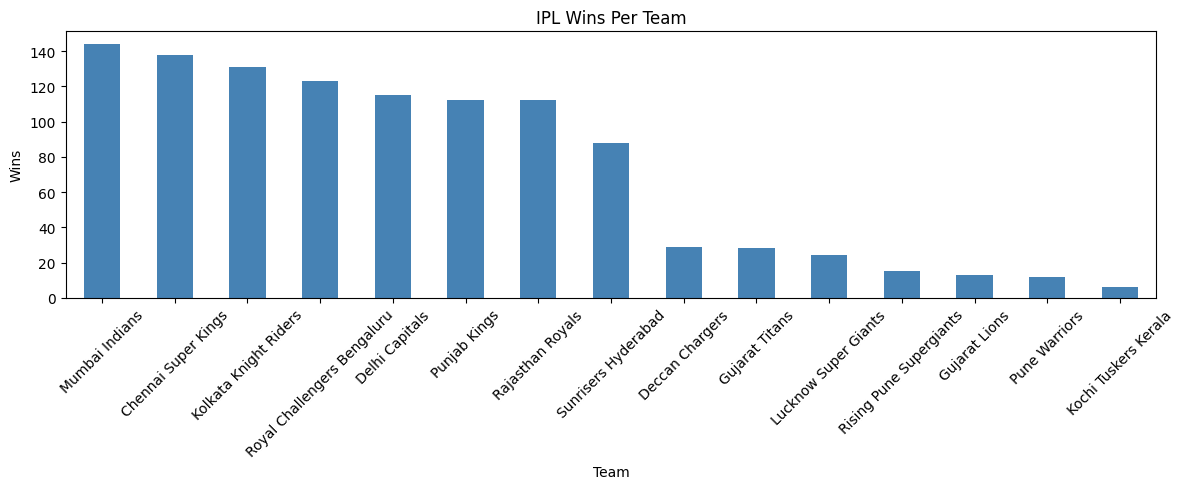

In [144]:
import matplotlib.pyplot as plt
wins_per_team.plot(kind="bar",color="steelblue",figsize=(12,5))
plt.title("IPL Wins Per Team")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()